# Shorter Notebook to debug the psf subtraction

In [19]:
#packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from astropy.io import fits
from astropy import units as u
import os 
import scopesim as sim

In [11]:
#Changement of folder (needed to work with ScopeSim)
os.chdir("../ScopeSim") #relative path to ScopeSim folder
print(os.getcwd())

c:\Users\Nyota\OneDrive - Universite de Liege\MASTER 3\TFE_AGN\Code\ScopeSim


In [39]:
example_FITS ='../debug/files/HL_Tau_prep_for_Scopesim.fits'

## 1. Useful functions & variables

In [45]:
def pc_to_mas(D, S):
    """Convert the size of an object in pc to its angular size in mas using the distance to the source

    Args:
        D (Quantity): Distance between the source and the detector [length]
        S (Quantity): Size of the object [length]

    Returns:
        Quantity: Angular size of the object in mas
    """
    D = D.to(u.pc)
    S = S.to(u.pc)
    mas = 2*np.arctan(S/2/D)
    mas = mas.to(u.mas)
    return mas


def mas_to_pc(theta, D):
    """Convert the angular size of an object in mas to its size in pc using the distance to the source

    Args:
        theta (Quantity): Angular size [angle]
        D (Quantity): Distance between the source and the detector [length]

    Returns:
        Quantity: Size of the object in pc
    """
    D = D.to(u.pc)
    theta = theta.to(u.radian)
    pc = 2*D*np.tan(theta/2)
    pc = pc.to(u.pc)
    return pc

## 2. Creation of 3 components source & psf

In [46]:
def Circular_Gaussian_profile(FWHM, flux, pixel_size, D_source, example_file, band_name, source_name, creating_FITS):
    """Generate a 2D circular Gaussian profile and create a FITS file.

    Args:
        FWHM (Quantity): FWHM of the source
        flux (Quantity): Total flux of the source received by the detector
        pixel_size (Quantity): Size of the pixel in pc

    Returns:
        Array(float): 2D array containing the 2D circular Gaussian profile
    """
    FWHM = FWHM.to(u.pc)
    FWHM = FWHM.value
    pixel_size = pixel_size.to(u.pc)
    #pixel_size = pixel_size.value
    flux = flux.to(u.Jy)
    flux = flux.value
    
    sigma = FWHM/(2* np.sqrt(2*np.log(2)))/pixel_size.value
    grid_length = int(10*sigma)
    
    if grid_length % 2 == 0:
        grid_length += 1
    Grid_size = (grid_length, grid_length)

    x = [i for i in range(Grid_size[0])]
    y = [i for i in range(Grid_size[1])]
    
    # The source is centered at the center of the grid
    x_c = int(Grid_size[0]/2) 
    y_c = int(Grid_size[1]/2)
    I = 1
    G = np.zeros((len(x), len(y)))
    for i in range(len(x)):
        for j in range(len(y)):
            G[i,j] = I*np.exp(-0.5*(((x[i]-x_c)/sigma)**2 + ((y[j]-y_c)/sigma)**2))
    
    # To normalize the gaussian following the value of the total flux of the source
    somme = np.sum(G)
    ratio = flux/somme 
    G *= ratio
    
    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G)[0]
        new_header['NAXIS2'] = np.shape(G)[1]
        new_header['CRPIX1'] = int(np.shape(G)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../debug/files/Circular_Gaussian_'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G

In [47]:
def Elliptical_Gaussian_profile(FWHM_x, FWHM_y, theta, flux, pixel_size, D_source, grid_length_factor, example_file, band_name, source_name, creating_FITS):
    """Generate a 2D Elliptical Gaussian profile.

    Args:
        FWHM_x (Quantity): FWHM of the source in x axis
        FWHM_y (Quantity): FWHM of the source in y axis
        flux (Quantity): Total flux of the source received by the detector
        pixel_size (Quantity): Size of the pixel in pc

    Returns:
        Array(float): 2D array containing the 2D elliptical Gaussian profile
    """
    FWHM_x = FWHM_x.to(u.pc)
    FWHM_x = FWHM_x.value
    FWHM_y = FWHM_y.to(u.pc)
    FWHM_y = FWHM_y.value
    theta = theta.to(u.radian)
    theta = theta.value 
    
    pixel_size = pixel_size.to(u.pc)
    #pixel_size = pixel_size.value
    flux = flux.to(u.Jy)
    flux = flux.value
    
    sigma_x = FWHM_x/(2* np.sqrt(2*np.log(2)))/pixel_size.value
    sigma_y = FWHM_y/(2* np.sqrt(2*np.log(2)))/pixel_size.value
    grid_length = int(grid_length_factor*np.max([sigma_x, sigma_y]))
    
    if grid_length % 2 == 0:
        grid_length += 1
    Grid_size = (grid_length, grid_length)

    x = [i for i in range(Grid_size[0])]
    y = [i for i in range(Grid_size[1])]
    
    # The source is centered at the center of the grid
    x_c = int(Grid_size[0]/2) 
    y_c = int(Grid_size[1]/2)
    I = 1
    G = np.zeros((len(x), len(y)))
    a = np.cos(theta)**2/(2*sigma_x**2)+np.sin(theta)**2/(2*sigma_y**2)
    c = np.cos(theta)**2/(2*sigma_y**2)+np.sin(theta)**2/(2*sigma_x**2) 
    b = -np.cos(theta)*np.sin(theta)/(2*sigma_x**2)+np.cos(theta)*np.sin(theta)/(2*sigma_y**2)
    
    for i in range(len(x)):
        for j in range(len(y)):
            G[i,j] = I*np.exp(-(a*(x[i]-x_c)**2 + 2*b*(x[i]-x_c)*(y[j]-y_c) + c*(y[j]-y_c)**2))
    
    # To normalize the gaussian following the value of the total flux of the source
    somme = np.sum(G)
    ratio = flux/somme 
    G *= ratio

    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G)[0]
        new_header['NAXIS2'] = np.shape(G)[1]
        new_header['CRPIX1'] = int(np.shape(G)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../debug/files/Elliptical_Gaussian_'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G

In [48]:
def pt_and_extended_sources_3(FWHM_polar_x, FWHM_polar_y, FWHM_disk_x, FWHM_disk_y, FWHM_unres, flux_polar, flux_disk, flux_unres, theta_polar, theta_disk, pixel_size, D_source,  grid_length_factor, d_offset, example_file, band_name, source_name, creating_FITS):
    
    G_unres = Circular_Gaussian_profile(FWHM_unres, 
                                        flux_unres, 
                                        pixel_size, D_source, example_file, band_name, source_name, False)
    
    G_polar = Elliptical_Gaussian_profile(FWHM_polar_x, FWHM_polar_y, 
                                          theta_polar, flux_polar, 
                                          pixel_size, D_source,  grid_length_factor, example_file, band_name, source_name, False)
    
    G_disk = Elliptical_Gaussian_profile(FWHM_disk_x, FWHM_disk_y, 
                                         theta_disk, flux_disk, 
                                         pixel_size, D_source, grid_length_factor, example_file, band_name, source_name, False)
    d_center_polar = int(np.shape(G_polar)[0]/2+ d_offset) 
        
    # Adding G_disk
    half_length_disk = int(np.shape(G_disk)[0]/2)

    for i in range(np.shape(G_disk)[0]):
        for j in range(np.shape(G_disk)[1]):
            G_polar[d_center_polar-half_length_disk + i, d_center_polar-half_length_disk + j] += G_disk[i,j]
            
    # Adding G_unres
    half_length_unres = int(np.shape(G_unres)[0]/2)
    
    for i in range(np.shape(G_unres)[0]):
        for j in range(np.shape(G_unres)[1]):
            G_polar[d_center_polar-half_length_unres + i, d_center_polar-half_length_unres + j] += G_unres[i,j]
            
    
    
    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G_polar)[0]
        new_header['NAXIS2'] = np.shape(G_polar)[1]
        new_header['CRPIX1'] = int(np.shape(G_polar)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G_polar)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../debug/files/3_Pt_and_Extended_Gaussian'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G_polar, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G_polar

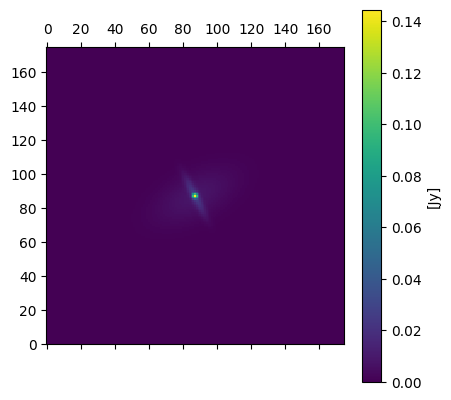

In [49]:
# Generation of the 2D Circinus with 3 components: the unres, the disk, and the polar ones
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc

CDELT = 3.90625 *u.mas


pxl_polar_x = 52
pxl_polar_y = 26
pxl_disk_x = pxl_polar_y
pxl_disk_y = 5
pxl_unres_x = 3 # mettre 3


theta_polar = 27*u.degree
theta_disk = theta_polar + 90*u.degree


FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 

flux_unres = 0.77*u.Jy
flux_disk = 1.61 *u.Jy
flux_polar = 7.79*u.Jy



G_pt_and_extended_3 = pt_and_extended_sources_3(FWHM_unres=FWHM_unres, flux_unres=flux_unres,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y, FWHM_disk_y=FWHM_disk_x, flux_disk=flux_disk, theta_disk=theta_disk,
                                              pixel_size=pixel_size_circinus, D_source=D_circinus, 
                                              grid_length_factor=10, d_offset=0,
                                              example_file=example_FITS, band_name='N', source_name="Circinus", 
                                              creating_FITS=True)


plt.matshow(G_pt_and_extended_3)
plt.ylim(0, np.shape(G_pt_and_extended_3)[1])
plt.colorbar(label='[Jy]')
plt.show()

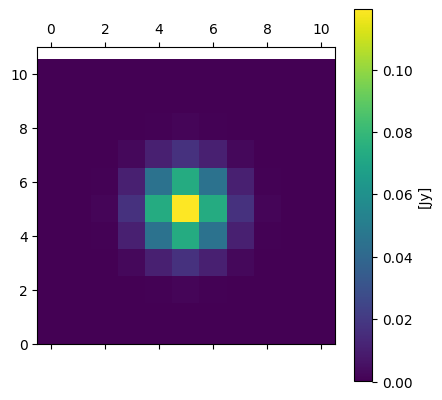

In [50]:
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc
pxl_unres_x = 3 
CDELT = 3.90625 *u.mas
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
flux_pt = 0.77*u.Jy

pt_source_077 = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size=pixel_size_circinus, D_source=D_circinus,
                                      example_file=example_FITS, band_name='N', source_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_FITS=True)

plt.matshow(pt_source_077)
plt.ylim(0, np.shape(pt_source_077)[1])
plt.colorbar(label='[Jy]')
plt.show()

## 3. SNR with psfsub

In [58]:
psf_file_unres_077 = '../debug/files/Circular_Gaussian_unres_pt_source_0.77Jy_N-band.fits'

file_circinus_3_components_N_band = '../debug/files/3_Pt_and_Extended_GaussianCircinus_N-band.fits'

N_band_pixel_scale = 6.79 *u.mas # given by the header of the image generated by ScopeSim
L_band_pixel_scale = 6.79 *u.mas #! To change, not the good value

exptime_1hour = 3600 *u.s

In [59]:
def create_fits(array, header, variable_name, object_name, band_name):
    new_header= header.copy()
    
    new_header['object'] = object_name
    
    file = '../debug/files/'+variable_name+'.fits'
    hdu = fits.PrimaryHDU(array, header=new_header)
    hdu.writeto(file, overwrite=True)
    return 0


def mean_Variance(rate, t):
    N = np.size(rate)
    return np.sum(rate)*t/N

In [60]:
def chop_nod_fct(metis_readout, dit, ndit, mode):
    image = metis_readout[1].data
    metis_readout[0].header['DIT'] = dit
    metis_readout[0].header['NDIT'] = ndit 
    metis_readout[0].header['EXPTIME'] = dit * ndit
    
    if mode == "img_n":
        pixel_scale = N_band_pixel_scale
    if mode == "img_lm":
        pixel_scale = L_band_pixel_scale
        
    chop_nod_offset = 3*u.arcsec
    chop_nod_offset = chop_nod_offset.to(u.mas)
    
    shift = int(chop_nod_offset.value / pixel_scale.value)
    quadrant_size = int(shift/2)
    screen_center = int(np.shape(image)[0]/2)
    border_min = int(screen_center - quadrant_size)
    border_max = int(screen_center+shift + quadrant_size)

    xmin, xmax = border_min, int(border_min+(border_max-border_min)/2)
    ymin, ymax = xmin, xmax

    beam_1 = image[ymin:ymax, xmin:xmax]
    beam_2 = image[ymin:ymax, xmin+shift:xmax+shift]
    beam_3 = image[ymin+shift:ymax+shift, xmin:xmax]
    beam_4 = image[ymin+shift:ymax+shift, xmin+shift:xmax+shift]
    bgsub_readout = beam_1 - beam_2 - beam_3 + beam_4 
    return bgsub_readout 

In [61]:
def SNR_TH(bgsub_Signal, Background, n_pix, ron, darkCurrent, dit, ndit):
    ron_per_pixel = ron/n_pix  # [e-/integration^(1/2)/pxl]
    darkCurrent_per_pixel = darkCurrent/n_pix # [e-/s/pxl]
    t = dit*ndit # [s]
    snr_th_map = t * bgsub_Signal / np.sqrt(t*bgsub_Signal + Background*t + t*darkCurrent_per_pixel + ndit*ron_per_pixel**2)
    
    # Mean of the snr_th on the subarray 
    """limits_source = subarray_size
    signal_coords_implane = (screen_center-limits_source, 
                             screen_center+limits_source, 
                             screen_center-limits_source, 
                             screen_center+limits_source)
    
    snr_th_cropped_mean = np.nanmean(snr_th_map[signal_coords_implane[0]:signal_coords_implane[1], signal_coords_implane[2]:signal_coords_implane[3]])"""
    
    return snr_th_map#, snr_th_cropped_mean

In [ ]:
def SNR_calculation(file, mode, chop_nod, exptime, SNR_implane_plot, SNR_readout_plot, psf_substraction, psf_file, object_name):
    """Determine the SNR 

    Args:
        file (FITS file): Input FITS file for METIS
        mode (string): either "img_n" or "img_lm"
        chop_nod (Boolean): True or False to perform (or not) the chop & nod
        exptime (Quantity): Time of exposition with unity following astropy package
        SNR_th (Boolean): True or False to perform (or not) the theoretical SNR (implane)
        SNR_empirical (Boolean): True or False to derive (or not) the Empirical SNR (readout)

    Returns:
        _type_: _description_
    """
    
    if mode == "img_n":
        band = "N-band"
    if mode == "img_lm":
        band = "L-band"
    
    
    # Sky observation
    cmd = sim.UserCommands(use_instrument="METIS", set_modes=[mode], properties={"!OBS.exptime": exptime.value, "!OBS.dit": None, "!OBS.ndit": None})
    metis = sim.OpticalTrain(cmd)
    metis.observe()      # blank sky
    
    sky_implane = metis.image_planes[0].data # [ph/s]
    sky_readout = metis.readout(exptime=exptime.value)[0]
    sky_readout_data = sky_readout[1].data
    dit, ndit = metis.cmds["!OBS.dit"], metis.cmds["!OBS.ndit"]
    
    # PSF substraction
    if psf_substraction == True:
        
        with fits.open(psf_file) as hdul:
            psf = sim.Source(image_hdu=hdul[0])
        metis.observe(psf)
        psf_implane = metis.image_planes[0].data # [ph/s]
        header_psf_implane = metis.image_planes[0].header
        psf_readout = metis.readout(dit=dit, ndit=ndit)[0]
        psf_readout_data = psf_readout[1].data
        header_psf_readout = psf_readout[1].header
        
        
    # Object observation
    with fits.open(file) as hdul:
        src = sim.Source(image_hdu=hdul[0])
    metis.observe(src)

    src_implane = metis.image_planes[0].data # [ph/s]
    header_src_implane = metis.image_planes[0].header
    
    
    #Chop & nod
    if chop_nod == True:
        metis['chop_nod'].include = True
        print("Chopping:", metis.cmds['!OBS.chop_offsets'])
        print("Nodding: ", metis.cmds['!OBS.nod_offsets'])
        
        src_readout = metis.readout(dit=dit, ndit=ndit)[0]
        header_src_readout = src_readout[1].header
        src_readout_data = src_readout[1].data
        ndit *= 4 #due to chop & nod
        
        bgsub_readout = chop_nod_fct(src_readout, dit, ndit, mode)
        #sky_readout_data = sky_readout[1].data[screen_center-quadrant_size:screen_center+quadrant_size, screen_center-quadrant_size:screen_center+quadrant_size]
        
    if chop_nod == False:
        src_readout  = metis.readout(dit=dit, ndit=ndit)[0] 
        src_readout_data = src_readout[1].data
        screen_center = int(np.shape(src_readout_data)[0]/2)
        header_src_readout = src_readout[1].header
        


    # Background substraction 
    if psf_substraction == False:
        bgsub_implane = src_implane - sky_implane
        if chop_nod == False:
            bgsub_readout = src_readout_data - sky_readout_data #[ADU]
        
    if psf_substraction == True and chop_nod == False:
        bgsub_implane = src_implane - psf_implane
        bgsub_readout = src_readout_data - psf_readout_data #[ADU]
    
        
    """bgsub_implane = np.where(bgsub_implane > 0, bgsub_implane, 0) #in case the substraction gives neg nbr
    bgsub_readout = np.where(bgsub_readout > 0, bgsub_readout, 0) #in case the substraction gives neg nbr"""

    # Detector information 
    #metis.cmds["!DET"]
    n_pix = 2048**2 
    ron = metis.cmds["!DET.readout_noise"] # [e-/integration^(1/2)]
    darkCurrent = metis.cmds['!DET.dark_current'] # [e-/s]
    gain = metis.cmds["!DET.gain"] # [e-/ADU]
    if mode == "img_n":
        QE = 0.8 # [-]
    if mode == "img_lm":
        QE =  0.8574456 # [-]
        
        
    # Theoritical SNR map (implane)
    snr_th_implane = SNR_TH(bgsub_implane*QE, sky_implane*QE, n_pix, ron, darkCurrent, dit, ndit)
    
    # Theoritical SNR map (readout)
    snr_th_readout = SNR_TH(bgsub_readout*gain, sky_readout_data*gain, n_pix, ron, darkCurrent, dit, ndit)
    
    # Estimation of SNR from the data
    # snr_emp_map, snr_emp_mean, snr_th_cropped = SNR_DATA(bgsub_readout*gain, sky_readout_data*gain, dit, ndit, subarray_size, distance_noise_subarray, chop_nod)
    
    
    """"PLOTS"""
   
        
    if SNR_implane_plot == True:
        if psf_substraction == True: 
            imsrcraw=plt.imshow(psf_implane, norm='log')
            plt.colorbar(imsrcraw, label='['+header_psf_implane['BUNIT']+']')
            plt.title('PSF Implane image '+band+' (with log norm)')
            plt.show()
            
        imsrcraw=plt.imshow(bgsub_implane, norm='log')
        plt.colorbar(imsrcraw, label='['+header_src_implane['BUNIT']+']')
        plt.title('Background substracted Implane image '+band+' (with log norm)')
        plt.show()
        
        plt.imshow(snr_th_implane)
        plt.colorbar(label="SNR")
        plt.title("Theoretical SNR (implane)")
        plt.xlabel('pxl')
        plt.ylabel('pxl')
        plt.show()
        
        
            
            
    # TODO: change the ticks to correspond to the pixel number of the screen
    if SNR_readout_plot == True:
        if psf_substraction == True: 
            imsrcraw=plt.imshow(psf_readout_data, norm='log')
            plt.colorbar(imsrcraw, label='['+header_psf_readout['BUNIT']+']')
            plt.title('PSF image (readout) (with log norm)')
            plt.show()
            
        imsrcraw=plt.imshow(bgsub_readout, norm='log')
        plt.colorbar(imsrcraw, label='['+header_src_readout['BUNIT']+']')
        plt.title('Background substracted readout image '+band+' (with log norm)')
        plt.show()
        
        plt.imshow(snr_th_readout)
        plt.colorbar(label="SNR")
        plt.title("Theoretical SNR (readout)")
        plt.xlabel('pxl')
        plt.ylabel('pxl')
        plt.show()
        
            
            
            
    """FITS file"""
    if SNR_implane_plot == True or SNR_readout_plot == True:
        # src
        create_fits(src_implane, header_src_implane, variable_name='src_IMPLANE', object_name=object_name, band_name=mode)
        create_fits(src_readout_data, header_src_readout, variable_name='src_READOUT', object_name=object_name, band_name=mode)
        
        # bgsub
        create_fits(bgsub_implane, header_src_implane, variable_name='bgsub_IMPLANE', object_name=object_name, band_name=mode)
        create_fits(bgsub_readout, header_src_readout, variable_name='bgsub_READOUT', object_name=object_name, band_name=mode)
        
        # snr 
        create_fits(snr_th_implane, header_src_implane,variable_name='SNR_th_IMPLANE', object_name=object_name, band_name=mode)
        create_fits(snr_th_readout, header_src_readout, variable_name='SNR_th_READOUT', object_name=object_name, band_name=mode)
        
        if psf_substraction == True: 
            # psf
            create_fits(psf_implane, header_psf_implane, variable_name='PSF_IMPLANE', object_name=object_name, band_name=mode)
            create_fits(psf_readout_data, header_src_readout, variable_name='PSF_READOUT', object_name=object_name, band_name=mode)
        
    return [src_readout_data, src_implane, bgsub_implane, bgsub_readout, snr_th_implane, snr_th_readout]

astar.scopesim.optics.optical_train - Observing empty field


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.04s/it]

astar.scopesim.effects.electronic - Requested exposure time: 3600.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.25s/it]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


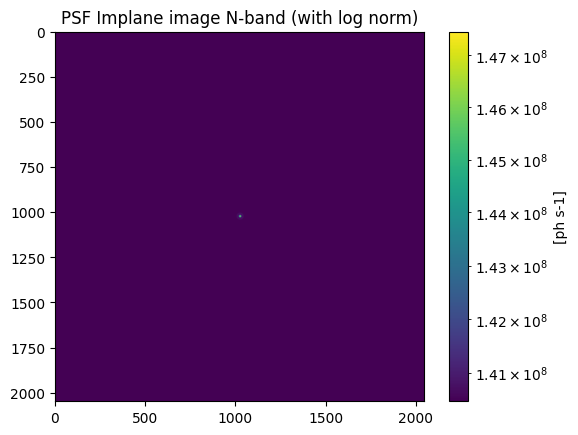

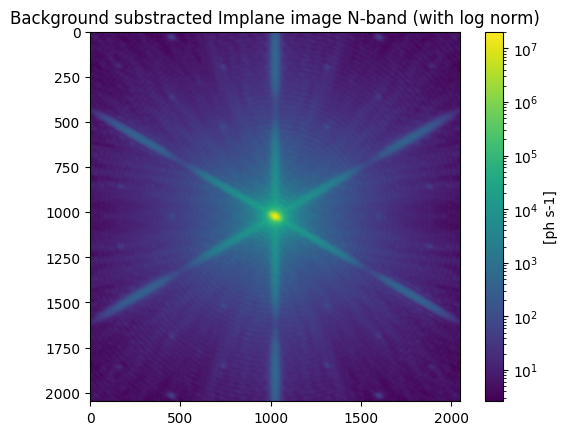

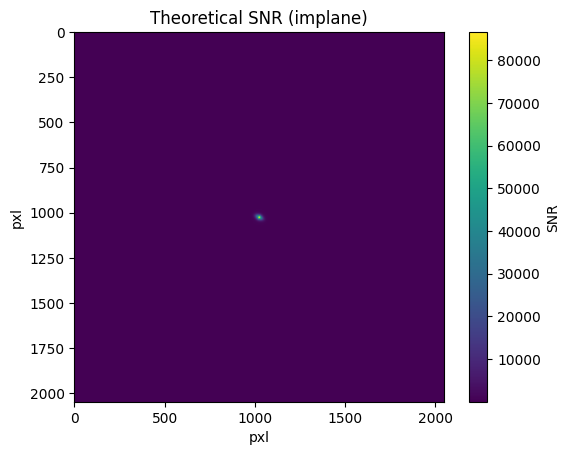

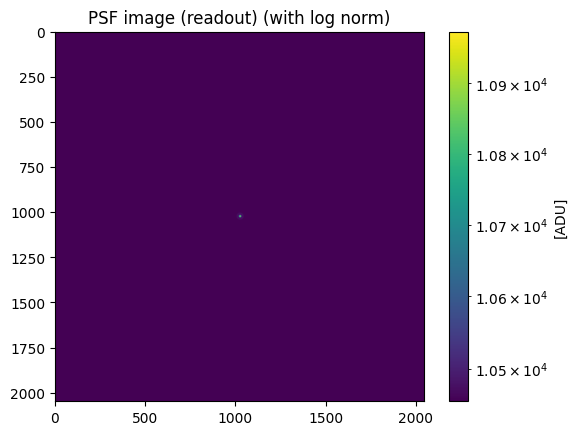

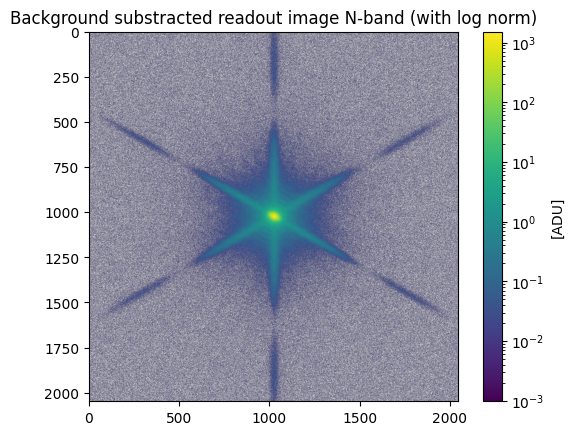

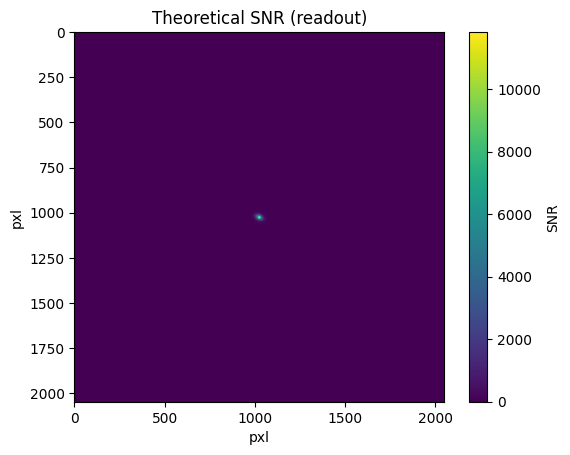

In [63]:
fsub_3 =SNR_calculation(file=file_circinus_3_components_N_band, mode="img_n", 
                chop_nod=False, exptime=exptime_1hour, 
                SNR_implane_plot=True, SNR_readout_plot=True, 
                psf_substraction=True, psf_file=psf_file_unres_077,
                object_name='3_source_with_psfsub')